# RL Link Adaptation (Patched for Sionna)

This notebook wires a DQN agent directly to Sionna's PHYAbstraction, replacing ILLA/OLLA.

In [1]:
# --- BOOTSTRAP / RESUME AGENT ---
import os
from tensorflow.keras import mixed_precision

mixed_precision.set_global_policy("mixed_float16")

from agent_dqn import DQNAgent
from mcs_table import NUM_MCS

STATE_DIM   = 3
MODEL_PATH  = "dqn_link_adapt.keras"  # saved next to the notebook

if "agent" in globals():
    print("Agent already exists in memory; keeping current weights.")
else:
    agent = DQNAgent(
        state_dim=STATE_DIM, num_actions=NUM_MCS,
        gamma=0.99, lr=1e-3,
        eps_start=1.0, eps_end=0.05, eps_decay=2e-4,
        replay_capacity=100_000, batch_size=256,
        target_sync=1000, seed=0
    )
    if os.path.exists(MODEL_PATH):
        agent.load(MODEL_PATH)
        # choose one:
        agent.eps = 0.0   # continue training with a bit of exploration
        # agent.eps = 0.00 # inference-only
        print(f"Loaded weights from {MODEL_PATH}")
    else:
        print("No saved model found; starting from scratch.")


2025-08-19 22:22:17.658129: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-19 22:22:17.949877: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1755631338.040332 1464958 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1755631338.068023 1464958 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1755631338.294616 1464958 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

Loaded weights from dqn_link_adapt.keras


In [2]:
# Imports
import numpy as np
import matplotlib.pyplot as plt

from agent_dqn import DQNAgent
from mcs_table import spectral_efficiency, NUM_MCS

# Sionna PHY Abstraction
from sionna.sys.phy_abstraction import PHYAbstraction, EESM

# Our adapter
from la_env import bind_phy_abs, set_current_sinr_db, get_effective_sinr_db, send_with_mcs
np.random.seed(0)

## 1) Build PHY Abstraction
We use EESM and bind it to our adapter. If you have a calibrated EESM (beta) table, load it here.

In [3]:
# Build PHY Abstraction (EESM)
eesm = EESM()             # optionally EESM(beta=...) if you have calibration
phy_abs = PHYAbstraction(eesm=eesm)
bind_phy_abs(phy_abs)

from la_env import configure_link

# If you’re on NR MCS Table 1 (up to 64-QAM):
configure_link(mcs_table_index=1, mcs_category=1, cb_size=8448)

# If you switch to 256-QAM:
# configure_link(mcs_table_index=2, mcs_category="table2", cb_size=8448)


In [4]:
from functools import lru_cache

def _bler_raw(mcs_idx: int, snr_db: float) -> float:
    snr_eff = 10.0**(float(snr_db)/10.0)
    b = float(phy_abs.get_bler(int(mcs_idx),
                               int(MCS_TABLE_INDEX),
                               int(MCS_CATEGORY),
                               int(CB_SIZE),
                               np.array([snr_eff]))[0])
    if not np.isfinite(b): b = 1.0
    return 0.0 if b < 0.0 else (1.0 if b > 1.0 else b)

@lru_cache(maxsize=200_000)
def bler_cached(mcs_idx: int, snr_tenths: int) -> float:
    return _bler_raw(int(mcs_idx), snr_tenths/10.0)

def bler_cache_clear(): bler_cached.cache_clear()

def bler_at(mcs, snr_db):  # used by runners
    return bler_cached(int(mcs), int(round(float(snr_db)*10)))


In [5]:
# === Init full 3GPP link object ===
from nr_link_full import NRLinkFull

full_link = NRLinkFull(
    carrier_freq_hz=3.5e9,
    scs_khz=30,
    n_prb=24,             # UE allocation; adjust to your scenario
    n_symb_slot=14,
    n_tx=1, n_rx=1,
    channel_model="TDL-C",
    delay_spread_s=100e-9,
    ue_speed_mps=3.0,
    pilot_spacing=(2,2),
    eesm_beta=1.0,
    seed=123
)
print("Full link ready.")


⚠️ Sionna TR 38.901 channel not found. Falling back to i.i.d. Rayleigh.
Full link ready.


## 2) DQN Agent & Helpers

In [6]:
# === ONE-CELL SETUP: constants, helpers, and RESUME-FRIENDLY agent init ===
import os
import numpy as np
from agent_dqn import DQNAgent
from mcs_table import spectral_efficiency, NUM_MCS

# ---- constants & helpers ----
STATE_DIM   = 3   # [sinr_db_norm, last_mcs_norm, last_ack]
LAMBDA_NACK = 3.0
MODEL_PATH  = "dqn_link_adapt.keras"   # saved next to the notebook

def build_state(sinr_db, last_mcs, last_ack):
    """Pack state vector with simple normalization."""
    return np.array([(sinr_db - 10.0)/5.0, last_mcs/27.0, float(last_ack)], dtype=np.float32)

def reward_fn(mcs, ack, bler_est=None):
    """Goodput minus distance from target BLER. Uses PI’s EMA if bler_est not provided."""
    gp = spectral_efficiency(int(mcs)) * int(ack)
    if bler_est is None:
        # uses the PI EMA we already maintain
        from math import fabs
        return gp - 0.2*fabs(ema_bler - BLER_TARGET)
    else:
        from math import fabs
        return gp - 0.2*fabs(float(bler_est) - BLER_TARGET)

# ---- resume-friendly agent init ----
if "agent" in globals():
    print("Using existing agent in memory (not reset).")
else:
    agent = DQNAgent(
        state_dim=STATE_DIM, num_actions=NUM_MCS,
        gamma=0.99, lr=1e-3,
        eps_start=1.0, eps_end=0.05, eps_decay=2e-4,
        replay_capacity=100_000, batch_size=256,
        target_sync=1000, seed=0
    )
    if os.path.exists(MODEL_PATH):
        agent.load(MODEL_PATH)
        agent.eps = 0.1   # small exploration if you’ll keep training (set 0.0 for inference-only)
        print(f"Loaded weights from {MODEL_PATH}")
    else:
        print("No saved model found; starting from scratch.")

# ---- optional handy commands (uncomment to use) ----
# Save after training:
# agent.save(MODEL_PATH); print(f"Saved to {MODEL_PATH}")

# Inference-only mode (no exploration):
# agent.load(MODEL_PATH); agent.eps = 0.0

MCS_TABLE_INDEX = 1   # 1: NR Table 1 (to 64-QAM); 2: NR Table 2 (to 256-QAM)
MCS_CATEGORY     = 1   # must be INT in your Sionna build (1 or 2)
CB_SIZE          = 8448
BLER_TARGET      = 0.10

Using existing agent in memory (not reset).


In [7]:
# ==== PI controller (overwrite) ====
import numpy as np
from mcs_table import NUM_MCS
MCS_MIN, MCS_MAX = 0, NUM_MCS-1

# Controller params (good defaults)
BLER_TARGET = globals().get("BLER_TARGET", 0.10)
ALPHA_BLER  = 0.05   # PI’s internal BLER EMA
Kp, Ki      = 1.05, 0.02
INT_CLAMP   = 5.0
DEADBAND    = 0.015

# PI state
ema_bler = BLER_TARGET
int_err  = 0.0
mcs_corr = 0.0

def pi_reset():
    global ema_bler, int_err, mcs_corr
    ema_bler = float(BLER_TARGET)
    int_err  = 0.0
    mcs_corr = 0.0

def pi_update_and_correct(mcs_rl: int, ack_pred: int) -> int:
    """Immediate PI using predicted ACK for the *candidate* action, then map to next MCS."""
    global ema_bler, int_err, mcs_corr

    # 1) update EMA(BLER) from predicted ACK (0/1)
    bler_inst = 1 - int(ack_pred)
    ema_bler = (1.0 - ALPHA_BLER)*ema_bler + ALPHA_BLER*float(bler_inst)

    # 2) error vs target
    e = ema_bler - float(BLER_TARGET)

    # 3) PI update with anti-windup
    int_err  = np.clip(int_err + e, -INT_CLAMP, INT_CLAMP)
    mcs_corr = mcs_corr + (Kp*e + Ki*int_err)

    # 4) map to integer MCS with asymmetric down-round + slope limit
    m_analog = float(mcs_rl) - float(mcs_corr)
    step_cap = 2 if e > 0.10 else 1

    if e > DEADBAND:
        m_target = int(np.floor(m_analog))              # aggressive down on error
        m_next   = max(int(mcs_rl) - step_cap, m_target)
    elif e < -DEADBAND:
        m_target = int(np.round(m_analog))              # gentle up
        m_next   = min(int(mcs_rl) + 1, m_target)
    else:
        m_next = int(np.round(m_analog))

    return int(np.clip(m_next, MCS_MIN, MCS_MAX))



In [8]:
# Feed back the TRUE ACK after transmission (helps PI climb when BLER < target)
def pi_feedback_with_true_ack(ack_true: int):
    global ema_bler
    ema_bler = (1.0 - ALPHA_BLER)*ema_bler + ALPHA_BLER*(1 - int(ack_true))


In [9]:
from mcs_table import NUM_MCS
MCS_MIN, MCS_MAX = 0, NUM_MCS-1

def allowed_max_mcs(snr_db: float, p_tgt: float, up_margin: int = 0) -> int:
    """
    Highest MCS whose BLER(snr_db) <= p_tgt.
    up_margin lets you be slightly bolder when under target (e.g., +1).
    """
    snr_db = float(snr_db)
    for m in range(MCS_MAX, MCS_MIN-1, -1):
        if bler_cached(m, int(round(snr_db*10))) <= p_tgt:
            return min(m + int(up_margin), MCS_MAX)
    return MCS_MIN


In [10]:
# === Minimal self-contained training loop (synthetic SINR) — 
import matplotlib.pyplot as plt

# --- config ---
EPISODES       = 1          # adjust as you like
STEPS_PER_EP   = 100
SEED           = 0
sinr_center_db = 8.0        # mean of synthetic SINR trace

# --- histories (recreate fresh) ---
rew_hist, ack_hist, se_hist = [], [], []

np.random.seed(SEED)

for ep in range(EPISODES):
    pi_reset()
    last_mcs, last_ack = 0, 1
    ep_rew = 0.0; ep_acks = 0; ep_se = 0.0

    # synthetic slow-fading SINR(dB): smooth + noise
    sinr_seq = (sinr_center_db
                + 2.0*np.sin(2*np.pi*np.arange(STEPS_PER_EP)/200.0)
                + 0.3*np.random.randn(STEPS_PER_EP))
    safe_streak = 0  # counts consecutive TTIs with BLER well below target

    for t in range(STEPS_PER_EP):
        
        # --- Effective SINR from your full link (per-TTI) ---
        avg_snr_db  = float(sinr_seq[t])
        sinr_eff_db = full_link.eff_sinr_db(avg_snr_db)

        # --- Build state & RL proposes a nominal action ---
        s      = build_state(sinr_eff_db, last_mcs, last_ack)
        mcs_rl = int(agent.select_action(s))

        # === STEP 6: EXECUTE ACTION WITH PI + ADAPTIVE CLAMP (this is the action we TRAIN on) ===
        # (a) Candidate you'd actually use before PI: cap the raw RL action at target-safe bound
        safe_cap = allowed_max_mcs(sinr_eff_db, BLER_TARGET, up_margin=0)
        m_pre    = min(mcs_rl, safe_cap)
        bler_pre = bler_cached(m_pre, int(round(sinr_eff_db*10)))
        ack_p    = int((1.0 - bler_pre) >= 0.5)

        # (b) Immediate PI correction based on predicted ACK for the candidate
        mcs_exec = int(pi_update_and_correct(mcs_rl, ack_p))

        # (c) Adaptive clamp (stricter when BLER high, slightly bolder when too safe)
        b_corr = bler_cached(mcs_exec, int(round(sinr_eff_db*10)))
        too_safe = (b_corr < (BLER_TARGET - 0.03))  # e.g. < 7% when target=10%
        
        if too_safe:
            safe_streak += 1
            # get gradually bolder when we've been too safe for a while
            p_probe  = 0.20 if safe_streak < 40 else 0.25
            margin   = 1 if safe_streak < 20 else 2
            cap_now  = allowed_max_mcs(sinr_eff_db, p_tgt=p_probe, up_margin=margin)
        else:
            safe_streak = 0
            cap_now  = allowed_max_mcs(sinr_eff_db, p_tgt=BLER_TARGET, up_margin=0)

        if mcs_exec > cap_now:
            mcs_exec = cap_now
            b_corr   = bler_cached(mcs_exec, int(round(sinr_eff_db*10)))  # recompute for the final MCS


        # (d) Draw TRUE ACK from final BLER and feed it back to PI (so it can climb when safe)
        ack_true = int(np.random.rand() > b_corr)
        pi_feedback_with_true_ack(ack_true)
        # === END STEP 6 ===

        # --- reward + learning (train on the EXECUTED action) ---
        sp = build_state(sinr_eff_db, mcs_exec, ack_true)
        r  = reward_fn(mcs_exec, ack_true, ema_bler)   # pass EMA so reward nudges toward target BLER

        agent.push(s, mcs_exec, r, sp, 0.0)           # <-- store EXECUTED action, not the raw RL proposal
        agent.train_step()                             # comment out for eval-only

        # --- book-keeping (use executed action / true ack) ---
        ep_rew  += r
        ep_acks += int(ack_true == 1)
        ep_se   += spectral_efficiency(mcs_exec)
        last_mcs, last_ack = mcs_exec, ack_true

    rew_hist.append(ep_rew / STEPS_PER_EP)
    ack_hist.append(ep_acks / STEPS_PER_EP)      # ~ 1 - BLER
    se_hist.append(ep_se / STEPS_PER_EP)

    print(f"ep {ep+1}/{EPISODES}  avg_reward={rew_hist[-1]:.3f}  "
          f"ACKrate={ack_hist[-1]:.3f}  avgSE={se_hist[-1]:.3f}  eps={getattr(agent,'eps',float('nan')):.2f}")


2025-08-19 22:22:41.954984: E tensorflow/core/util/util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.
I0000 00:00:1755631361.958889 1465026 service.cc:152] XLA service 0x7daaa40041b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1755631361.958919 1465026 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4070 Laptop GPU, Compute Capability 8.9
2025-08-19 22:22:41.996949: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1755631362.035829 1465026 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1755631362.227446 1465026 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


ep 1/1  avg_reward=3.715  ACKrate=0.950  avgSE=3.942  eps=0.00


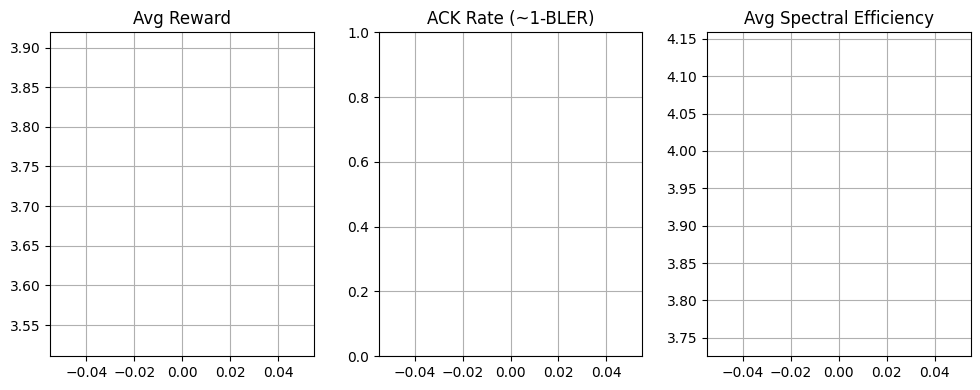

In [11]:
# Plots
plt.figure(figsize=(10,4))
plt.subplot(1,3,1); plt.plot(rew_hist); plt.title('Avg Reward'); plt.grid(True)
plt.subplot(1,3,2); plt.plot(ack_hist); plt.title('ACK Rate (~1-BLER)'); plt.ylim(0,1); plt.grid(True)
plt.subplot(1,3,3); plt.plot(se_hist); plt.title('Avg Spectral Efficiency'); plt.grid(True)
plt.tight_layout(); plt.show()


In [12]:
# Quick sanity: effective SINR distribution looks reasonable
vals = []
for k in range(500):
    avg = 8.0 + 2.0*np.sin(2*np.pi*k/250.0)
    vals.append(full_link.eff_sinr_db(avg))
print(f"Eff-SINR: mean={np.mean(vals):.2f} dB, std={np.std(vals):.2f} dB, "
      f"min={np.min(vals):.2f}, max={np.max(vals):.2f}")


Eff-SINR: mean=2.99 dB, std=0.71 dB, min=1.08, max=4.66


In [13]:
MODEL_PATH = "dqn_link_adapt.keras"
agent.save(MODEL_PATH)
print(f"Saved to {MODEL_PATH}")

Saved to dqn_link_adapt.keras


In [14]:
from mcs_table import NUM_MCS
MCS_MIN, MCS_MAX = 0, NUM_MCS-1

def allowed_max_mcs(snr_db: float, p_tgt: float, up_margin: int = 0) -> int:
    """
    Highest MCS whose BLER(snr_db) <= p_tgt.
    You can allow a small upward margin (e.g., +1) if you want a bit more aggressiveness.
    """
    snr_db = float(snr_db)
    for m in range(MCS_MAX, MCS_MIN-1, -1):
        if bler_cached(m, int(round(snr_db*10))) <= p_tgt:
            return min(m + int(up_margin), MCS_MAX)
    return MCS_MIN


In [15]:
# Feed back the TRUE ACK to PI after transmission (no change to MCS in this TTI)
def pi_feedback_with_true_ack(ack_true: int):
    global ema_bler
    # reuse the same ALPHA_BLER used inside PI
    ema_bler = (1.0 - ALPHA_BLER)*ema_bler + ALPHA_BLER*(1 - int(ack_true))

In [16]:
# === Convergence comparison: RL(+PI) vs OLLA ===
import numpy as np
import math

# --- Config ---
BLER_TARGET   = globals().get("BLER_TARGET", 0.10)
ALPHA_EMA     = 0.05         # BLER EMA for convergence measurement
EPS_BAND      = 0.03         # ±3% band around target
HOLD_STEPS    = 200          # must stay within band this long to "settle"
STEP_DB       = -3.0         # channel step at t0 (dB)
BASE_DB       = 8.0          # pre-step average SNR driver (dB)
SIN_FREQ      = 1/250.0      # slow sinusoid in driver
NOISE_STD     = 0.30         # driver noise (dB)
T_TOTAL       = 4000         # TTIs
T_SWITCH      = 2000         # when the step happens
SEED          = 1234         # reproducibility

# --- Utilities ---
def ema_seq(x, alpha=ALPHA_EMA):
    y = np.empty_like(x, dtype=float); s = float(x[0])
    for i, xi in enumerate(x):
        s = (1-alpha)*s + alpha*xi
        y[i] = s
    return y

def make_step_driver(T=T_TOTAL, t0=T_SWITCH, base_db=BASE_DB, step_db=STEP_DB, noise_std=NOISE_STD, seed=SEED):
    rng = np.random.default_rng(seed)
    t = np.arange(T)
    sinr = base_db + 2.0*np.sin(2*np.pi*t*SIN_FREQ) + noise_std*rng.standard_normal(T)
    sinr[t0:] += step_db
    return sinr, t0

def bler_at(mcs, snr_db):
    # always use cached accessor (fast, sanitized)
    return float(bler_cached(int(mcs), int(round(float(snr_db)*10))))

def mcs_throughput(m):
    # spectral_efficiency(m) is your helper; multiply by success prob for "expected goodput"
    return float(spectral_efficiency(int(m)))

def compare_convergence_metrics(acks, mcss, sinr_driver, t0, p_tgt=BLER_TARGET, eps=EPS_BAND, hold=HOLD_STEPS):
    import math, numpy as np
    acks = np.array(acks, int)
    bler = 1 - acks
    ema  = ema_seq(bler, alpha=ALPHA_EMA)   # this is the *reporting* EMA

    # 1) Settling: enter [target±band] OR be at safe cap with EMA <= upper band
    lo, hi = p_tgt - eps, p_tgt + eps
    run = 0; settle = math.inf
    for i in range(t0, len(ema)):
        eff_i  = full_link.eff_sinr_db(float(sinr_driver[i]))
        safe_i = allowed_max_mcs(eff_i, p_tgt=p_tgt, up_margin=0)
        in_band = (lo <= ema[i] <= hi)
        at_cap  = (mcss[i] >= safe_i) and (ema[i] <= hi)
        if in_band or at_cap:
            run += 1
            if run >= hold:
                settle = i - t0
                break
        else:
            run = 0

    # 2) First-drop latency: time to reach a safe MCS for the new channel
    eff0 = full_link.eff_sinr_db(float(sinr_driver[t0]))
    safe_after = allowed_max_mcs(eff0, p_tgt=p_tgt, up_margin=0)
    t_first_drop = math.inf
    for i in range(t0, len(mcss)):
        if mcss[i] <= safe_after:
            t_first_drop = i - t0
            break

    # 3) Overshoot / 4) IAE / 5) Pre/Post goodput
    overshoot = float(np.max(ema[t0:] - p_tgt)) if len(ema) > t0 else float('nan')
    iae = float(np.sum(np.abs(ema[t0:] - p_tgt)))
    def gp_seq(mm, aa): return [mcs_throughput(m)*a for m,a in zip(mm, aa)]
    pre_gp  = float(np.mean(gp_seq(mcss[max(0,t0-1000):t0], acks[max(0,t0-1000):t0]))) if t0>0 else float('nan')
    post_gp = float(np.mean(gp_seq(mcss[t0:], acks[t0:]))) if t0<len(mcss) else float('nan')

    return {"settling": settle, "first_drop": t_first_drop, "overshoot": overshoot, "IAE": iae,
            "pre_gp": pre_gp, "post_gp": post_gp}


# --- OLLA baseline (offset-based) ---
def run_olla_episode(sinr_driver, p_tgt=BLER_TARGET, delta_down_db=0.05, seed=SEED):
    """
    Standard OLLA with offset o_db:
      o_db <- o_db + Δ_up on ACK, o_db <- o_db - Δ_down on NACK
      Choose MCS as highest with BLER<=target using sinr_hat = eff_sinr + o_db
      Δ_up/Δ_down set so steady-state BLER ≈ p_tgt via Δ_up/(Δ_up+Δ_down)=p_tgt.
    """
    # derive Δ_up to hit target: p = Δ_up / (Δ_up + Δ_down) => Δ_up = p/(1-p) * Δ_down
    delta_up_db = float(p_tgt/(1.0 - p_tgt) * delta_down_db)

    rng = np.random.default_rng(seed)
    us  = rng.random(len(sinr_driver))  # shared uniforms for fairness if you want to reuse

    acks = []; mcss = []
    o_db = 0.0

    last_mcs, last_ack = 0, 1
    for t, avg_db in enumerate(sinr_driver):
        # Effective SINR from full link if available
        try:
            eff_db = full_link.eff_sinr_db(float(avg_db))
        except Exception:
            eff_db = float(avg_db)
        snr_hat = eff_db + o_db

        mcs = choose_mcs_olla(snr_hat, p_tgt=p_tgt)

        bler = bler_at(mcs, eff_db)  # NOTE: ACK/NACK is based on true eff. SINR, not the offset
        ack  = int(us[t] > bler)

        # OLLA update
        if ack == 1:
            o_db += delta_up_db
        else:
            o_db -= delta_down_db

        acks.append(ack); mcss.append(mcs)
        last_mcs, last_ack = mcs, ack

    return np.array(mcss, int), np.array(acks, int)

def run_rl_episode(sinr_driver, agent, seed=1234, debug_first=0):
    import numpy as np
    acks, mcss = [], []

    # Greedy eval
    if hasattr(agent, "eps"): agent.eps = 0.0
    pi_reset()

    safe_streak = 0                  # local streak counter for this run
    last_mcs, last_ack = 0, 1

    for t, avg_db in enumerate(sinr_driver):
        # 1) Effective SINR for this TTI
        try:
            eff_db = full_link.eff_sinr_db(float(avg_db))
        except Exception:
            eff_db = float(avg_db)

        # 2) RL proposes a nominal action
        s      = build_state(eff_db, last_mcs, last_ack)
        mcs_rl = int(agent.select_action(s))

        # 3) PI-immediate using predicted ACK for a realistic pre-cap candidate
        safe_cap = allowed_max_mcs(eff_db, p_tgt=BLER_TARGET, up_margin=0)
        m_pre    = min(mcs_rl, safe_cap)
        bler_pre = bler_cached(m_pre, int(round(eff_db*10)))
        ack_p    = int((1.0 - bler_pre) >= 0.5)
        mcs      = int(pi_update_and_correct(mcs_rl, ack_p))

        # 4) BLER for PI-adjusted (pre-cap) MCS
        b_corr = bler_cached(mcs, int(round(eff_db*10)))

        # 5) Adaptive clamp: stricter when BLER high, bolder when too safe
        too_safe = (b_corr < (BLER_TARGET - 0.03))  # e.g., BLER < 0.07 if target=0.10
        if too_safe:
            safe_streak += 1
            p_probe = 0.20 if safe_streak < 40 else 0.25
            margin  = 1 if safe_streak < 20 else 2
            cap_now = allowed_max_mcs(eff_db, p_tgt=p_probe, up_margin=margin)
        else:
            safe_streak = 0
            cap_now = allowed_max_mcs(eff_db, p_tgt=BLER_TARGET, up_margin=0)

        if mcs > cap_now:
            mcs = cap_now
            b_corr = bler_cached(mcs, int(round(eff_db*10)))  # recompute for final MCS

        # 6) Draw TRUE ACK and feed back to PI so it can climb when too safe
        ack = int(np.random.rand() > b_corr)
        pi_feedback_with_true_ack(ack)

        if t < debug_first:
            print(f"[t={t:02d}] eff={eff_db:5.2f} | RL={mcs_rl:2d} m_pre={m_pre:2d} "
                  f"-> mcs={mcs:2d} cap_now={cap_now:2d} | bler_final={b_corr:5.3f} ack={ack}")

        acks.append(ack); mcss.append(mcs)
        last_mcs, last_ack = mcs, ack

    return np.array(mcss, int), np.array(acks, int)



# --- Run both on the same step-change channel and compare ---
sinr_seq, t0 = make_step_driver()
# For strict fairness of random ACK draws, you can set the same global numpy seed before each run:
np.random.seed(SEED)
mcs_rl, ack_rl = run_rl_episode(sinr_seq, agent, seed=SEED)

print("MCS around step (t0-5..t0+10):", mcs_rl[max(0,t0-5):t0+10])
print("ACK around step (t0-5..t0+10):", ack_rl[max(0,t0-5):t0+10],
      "ACK rate post-step:", np.mean(ack_rl[t0:]))

np.random.seed(SEED)
mcs_ol, ack_ol = run_olla_episode(sinr_seq, p_tgt=BLER_TARGET, delta_down_db=0.05, seed=SEED)

rl_metrics = compare_convergence_metrics(ack_rl, mcs_rl, sinr_seq, t0, p_tgt=BLER_TARGET)
ol_metrics = compare_convergence_metrics(ack_ol, mcs_ol, sinr_seq, t0, p_tgt=BLER_TARGET)

def fmt(v): 
    return ("∞" if (isinstance(v, float) and not np.isfinite(v)) or v==math.inf else f"{v:.0f}") if isinstance(v,(int,float)) else str(v)

print("=== Convergence (step -3 dB at t0) ===")
print(f"Target BLER={BLER_TARGET:.2f}, band=±{EPS_BAND:.2f}, hold={HOLD_STEPS} TTIs")

print("\n-- RL(+PI) --")
print("  Settling time (TTIs):", fmt(rl_metrics['settling']))
print("  First-drop latency  :", fmt(rl_metrics['first_drop']))
print("  Overshoot (EMA)     :", f"{rl_metrics['overshoot']:.3f}")
print("  IAE after t0        :", f"{rl_metrics['IAE']:.1f}")
print("  Pre/Post Avg GP     :", f"{rl_metrics['pre_gp']:.3f} / {rl_metrics['post_gp']:.3f}")

print("\n-- OLLA --")
print("  Settling time (TTIs):", fmt(ol_metrics['settling']))
print("  First-drop latency  :", fmt(ol_metrics['first_drop']))
print("  Overshoot (EMA)     :", f"{ol_metrics['overshoot']:.3f}")
print("  IAE after t0        :", f"{ol_metrics['IAE']:.1f}")
print("  Pre/Post Avg GP     :", f"{ol_metrics['pre_gp']:.3f} / {ol_metrics['post_gp']:.3f}")


# (Optional) return metrics dicts to reuse later
RESULTS_CONV = {"RL_PI": rl_metrics, "OLLA": ol_metrics, "t0": t0}


MCS around step (t0-5..t0+10): [ 9 10 10 10  7  7  7  7  7  7  7  7  7  7  7]
ACK around step (t0-5..t0+10): [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1] ACK rate post-step: 0.98


NameError: name 'choose_mcs_olla' is not defined

In [ ]:
mcs_dbg, ack_dbg = mcs_rl[:30], ack_rl[:30]
print(mcs_dbg)
print(ack_dbg, "ACK rate:", np.mean(ack_dbg))


In [ ]:
eff_probe = np.median([full_link.eff_sinr_db(float(x)) for x in sinr_seq[:200]])
from mcs_table import NUM_MCS
print("Eff≈", round(eff_probe,2), "dB  BLER[0..15]:",
      [(m, round(bler_cached(m, int(round(eff_probe*10))),3)) for m in range(min(16, NUM_MCS))])

In [ ]:
print("RL MCS @ step:", mcs_rl[max(0,t0-3):t0+6])
print("RL ACK @ step:", ack_rl[max(0,t0-3):t0+6])
print("OL MCS @ step:", mcs_ol[max(0,t0-3):t0+6])
print("OL ACK @ step:", ack_ol[max(0,t0-3):t0+6])